In [81]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb

In [82]:
df = pd.read_csv("data/celsius_a_fahrenheit.csv")
df.head()

celcius = np.array(df['Celsius'], dtype=float)
farenheit = np.array(df['Fahrenheit'], dtype=float)

print(f"Celsius: {celcius[:5]}")
print(f"Fahrenheit: {farenheit[:5]}")



Celsius: [-50. -40. -30. -20. -10.]
Fahrenheit: [-58. -40. -22.  -4.  14.]


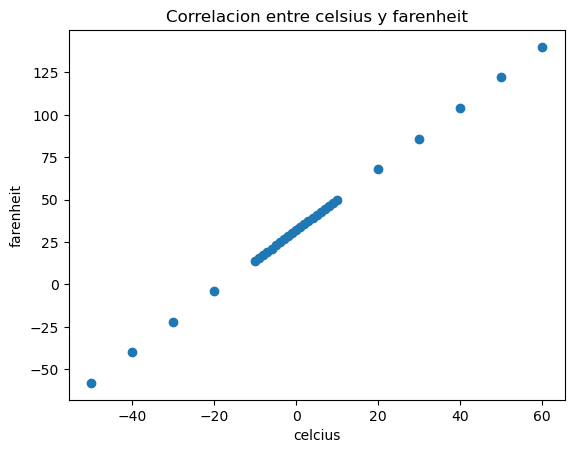

In [83]:
plt.scatter(celcius,farenheit)
plt.title('Correlacion entre celsius y farenheit')
plt.xlabel('celcius')
plt.ylabel('farenheit')

plt.show()


<Axes: xlabel='Celsius', ylabel='Fahrenheit'>

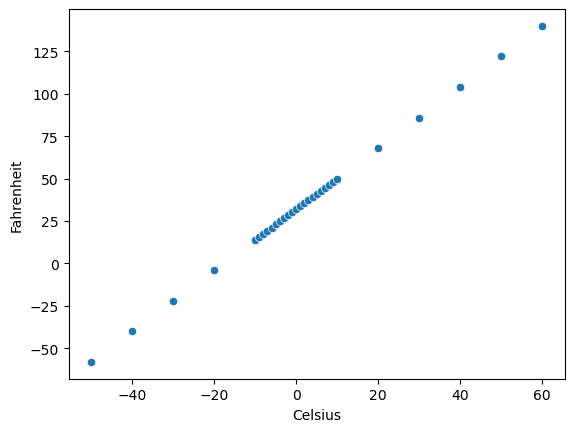

In [84]:
sb.scatterplot(x='Celsius', y='Fahrenheit', data=df)

In [85]:
X_train = celcius
Y_train = farenheit

In [86]:
print("Creando el modelo")
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(units=1))

Creando el modelo


In [87]:
print('Compilando el modelo')
model.compile(
    optimizer=tf.keras.optimizers.Adam(1.0),
    loss='mean_squared_error'
)

Compilando el modelo


In [ ]:
print('entrenadno el modelo')
epochs_hist = model.fit(X_train, Y_train, epochs=150)

entrenadno el modelo
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - loss: 5549.9614
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 2956.8218
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1415.5641
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 841.9437
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 985.1956
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1425.3652
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 1759.6321
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1803.8932
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 1584.0533
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1221.4689
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 847.9883
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 564.2978
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 421.5806
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 416.6538
Epoch 15/100
1/1 ━━━━━━━━━━

In [89]:
print('evaluando el modelo entrenado')
print('keys:')
print(epochs_hist.history.keys())

evaluando el modelo entrenado
keys:
dict_keys(['loss'])


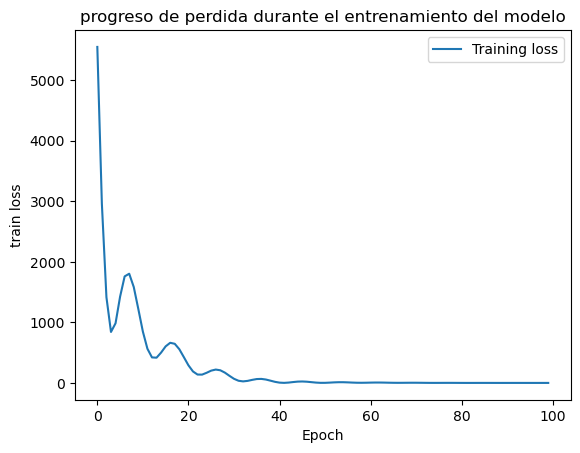

In [90]:
plt.plot(epochs_hist.history['loss'])
plt.title('progreso de perdida durante el entrenamiento del modelo')
plt.xlabel('Epoch')
plt.ylabel('train loss')
plt.legend(['Training loss'])
plt.show()

In [91]:
Temp_C = 100
Temp_C_array = np.array([[Temp_C]])
Temp_F = model.predict(Temp_C_array)
print('temperatura de prediccion: '+str(Temp_F))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
temperatura de prediccion: [[210.5869]]


In [92]:
Temp_F = 9/5 * Temp_C + 32
print('temperatura de ecuacion: '+ str(Temp_F))

temperatura de ecuacion: 212.0


In [93]:
oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)
modelo = tf.keras.Sequential([oculta1,oculta2,salida])

print(oculta1.get_weights())
print(oculta2.get_weights())
print(salida.get_weights())

[array([[-0.33001357,  0.17178655,  0.04842877]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[ 0.8199465 ,  0.70132065, -0.9241111 ],
       [-0.39467597, -0.66917396,  0.34287977],
       [-0.9528475 ,  0.4633007 ,  0.8752463 ]], dtype=float32), array([0., 0., 0.], dtype=float32)]
[array([[ 0.56178045],
       [-0.13496244],
       [-0.57199997]], dtype=float32), array([0.], dtype=float32)]


c:\Users\herna\anaconda3\envs\notebooks\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
